<div >
<img src = "figs/ans_banner_1920x200.png" />
</div>

# Caso-taller:  Segmentación de Clientes con Clustering Jerárquico y DBSCAN

El objetivo de este caso-taller es analizar una base de datos ficticia sobre clientes de una tienda y buscar encontrar grupos de clientes que permitan generar estrategias de marketing focalizadas. La base se encuentra en los `Archivos de Laboratorio` en la carpeta `data` y cuenta con 200 observaciones y 5 variables:

- `Id_Cliente`: identificador de cliente.
- `Genero`: género del cliente: Mujer, Hombre
- `Edad`: edad en años
- `Ingreso`: ingresos anuales
- `Puntaje_Gasto`: es una variable que mide cuán a menudo un cliente compra en la tienda, siendo 100 el puntaje más alto.


## Instrucciones generales

1. Para desarrollar el *cuaderno* primero debe descargarlo.

2. Para responder cada inciso deberá utilizar el espacio debidamente especificado.

3. La actividad será calificada sólo si sube el *cuaderno* de jupyter notebook con extensión `.ipynb` en la actividad designada como "entrega calificada por el personal".

4. El archivo entregado debe poder ser ejecutado localmente por el tutor. Sea cuidadoso con la especificación de la ubicación de los archivos de soporte, guarde la carpeta de datos en el mismo `path` de su cuaderno, por ejemplo: `data`.

## Integrante

|**Nombre**|**Email**|
|---|---|
|Mendoza Canales Hubert Ronald|h.mendozac@uniandes.edu.co|

## Desarrollo


#### Config

##### Carga de Bibliotecas

In [ ]:
from __future__ import annotations

%load_ext autoreload
%autoreload 2

# python
import os
import ssl
import sys
import csv
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import session_info

from pathlib import Path
from inspect import cleandoc

# variables categoricas
import gower

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, scale
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.manifold import TSNE, MDS

# stat
from scipy import stats
from scipy.stats import ttest_ind, f_oneway
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import fcluster

# statsmodels
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.api as sm
from statsmodels.formula.api import ols

# skleann metrics
from sklearn.metrics import silhouette_score

# typings
from pandas import DataFrame as PandasDF
from typing import List, Dict, Union

# setup
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('max_colwidth', None)
# decimals
np.set_printoptions(precision=6)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


##### Información de Sesión

In [18]:
session_info.show(html=False)

-----
gower               NA
matplotlib          3.10.0
numpy               1.26.4
pandas              2.3.1
scipy               1.15.3
seaborn             0.13.2
session_info        v1.0.1
sklearn             1.7.1
statsmodels         0.14.5
-----
IPython             8.37.0
jupyter_client      8.6.3
jupyter_core        5.8.1
jupyterlab          4.4.5
notebook            7.4.5
-----
Python 3.10.11 (v3.10.11:7d4cc5aa85, Apr  4 2023, 19:05:19) [Clang 13.0.0 (clang-1300.0.29.30)]
macOS-10.15.7-x86_64-i386-64bit
-----
Session information updated at 2025-08-31 17:39


### utils

In [19]:
# utils

# desabilitar SSL verificacion para entornos locales
# cargar el dataset sklearn
if not os.environ.get('CI'):
    ssl._create_default_https_context =\
        ssl._create_unverified_context
          
# rutas absolutas
here: Path = Path.cwd().absolute()
data: Path = here / 'data'
customer_data: Path = data / 'datos_clientes.csv'

### 1.Carga de datos 

En la carpeta `data` se encuentra el archivo `datos_clientes.csv` cargue estos datos en su *cuaderno*. 

In [20]:
# Utilice este espacio para escribir el código.
df: PandasDF = pd.read_csv(customer_data)
df.columns = df.columns.str.strip()
df.head()

,Id_Cliente,Genero,Edad,Ingreso,Puntaje_Gasto
0,1,Mujer,41,98115.05,39
1,2,Mujer,20,35458.14,75
2,3,Mujer,68,59872.08,55
3,4,Hombre,63,48508.93,51
4,5,Mujer,31,44431.11,54


(Utilice este espacio para describir su procedimiento)

Se cargan el dataset `datos_clientes.csv` que estará en el la carpeta "`data` en la misma raiz del presente notebook. Asismimo se limpia los nombres de las columnas para facilitar la selección de variables (Al parecer una tenía espacios en blanco). 

```bash
.
|- data
|  |- datos_clientes.csv
|- S4_LC_Taller_Jerarquico_DBSCAN.ipynb
```

### 2. Análisis preliminar. 

Antes de comenzar el análisis de segmentación utilice estadísticas descriptivas para explorar la variables que se encuentran en los datos. En su análisis mencione si hay patrones que surgen del examen descriptivo de los datos; entre ellos si hay diferencias en los ingresos y los puntajes de gastos para mujeres y hombres, por grupos etarios (18-24, 25-34, 35-44, 45-54, 55-64, y 65+), y por grupos etarios y género. Discuta además si estas diferencias son estadísticamente significativas.

=== Análisis Descriptivo ===
       Ingreso                                                               \
         count          mean           std       min         25%        50%   
Genero                                                                        
Hombre    88.0  62126.660455  26765.492953  13458.02  45003.0800  61706.565   
Mujer    112.0  59444.135714  25920.459216  15766.84  40013.4125  59355.305   

                              Puntaje_Gasto                                  \
               75%        max         count       mean       std  min   25%   
Genero                                                                        
Hombre  77731.3025  138584.52          88.0  48.511364  27.89677  1.0  24.5   
Mujer   76788.3875  126685.78         112.0  51.526786  24.11495  5.0  35.0   

                          
         50%   75%   max  
Genero                    
Hombre  50.0  70.0  97.0  
Mujer   50.0  73.0  99.0  

--- Análisis por Grupos de Edad ---
Tamaño 

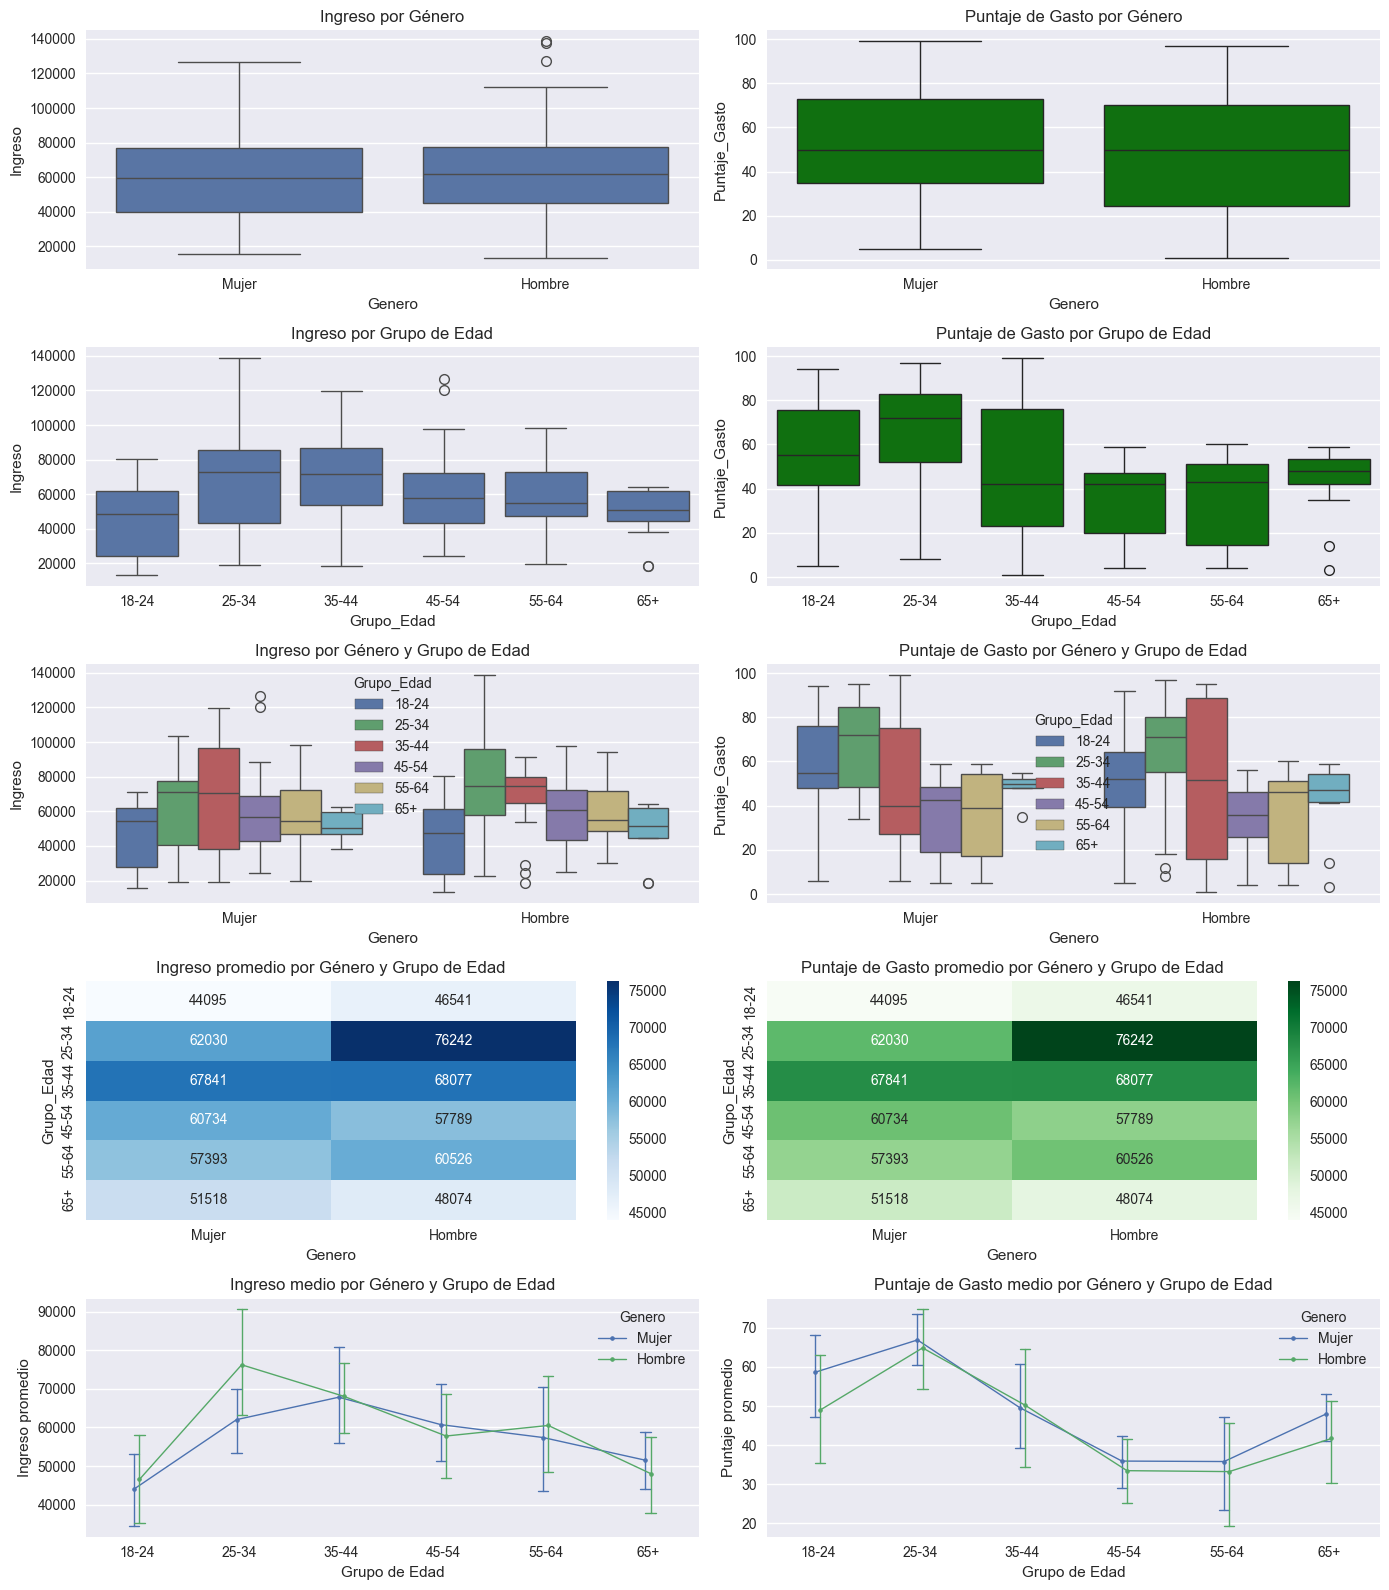

In [21]:
def analisis_preliminar(df):
    print("=== Análisis Descriptivo ===")
    print(df.groupby('Genero', observed=True)[['Ingreso', 'Puntaje_Gasto']].describe())

        # Creación de grupos de edad y análisis
    print("\n--- Análisis por Grupos de Edad ---")
    bins = [18, 24, 34, 44, 54, 64, np.inf]
    labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
    df['Grupo_Edad'] = pd.cut(df['Edad'], bins=bins, labels=labels, right=False)
    
    # --- Revisión de tamaños de grupos ---
    conteo = df["Grupo_Edad"].value_counts()
    print("Tamaño de grupos:\n", conteo, "\n")
    
    print("\n=== Comparación de Medias ===")
    print(df.groupby(['Genero', 'Grupo_Edad'], observed=True)[['Ingreso', 'Puntaje_Gasto']].mean())

        # Pruebas de significancia por género
    print("\n=== Pruebas de Significancia (t-test por Género) ===")
    hombres = df[df['Genero'] == 'Hombre']
    mujeres = df[df['Genero'] == 'Mujer']
    for col in ['Ingreso', 'Puntaje_Gasto']:
        t_stat, p_val = stats.ttest_ind(hombres[col], mujeres[col], equal_var=False)
        print(f"{col}: t={t_stat:.3f}, p={p_val:.3f}")

    # ANOVA de un factor por grupo de edad
    print("\n=== ANOVA de un factor por Grupo de Edad ===")
    for col in ['Ingreso', 'Puntaje_Gasto']:
        grupos = [g[col].values for _, g in df.groupby('Grupo_Edad', observed=True)]
        f_stat, p_val = stats.f_oneway(*grupos)
        print(f"{col}: F={f_stat:.3f}, p={p_val:.3f}")

        # Post-hoc Tukey
        tukey = pairwise_tukeyhsd(df[col], df['Grupo_Edad'])
        print(f"\nPost-hoc Tukey para {col}:\n", tukey)

        # Kruskal-Wallis como prueba robusta
        H_stat, p_kw = stats.kruskal(*grupos)
        print(f"Kruskal-Wallis para {col}: H={H_stat:.3f}, p={p_kw:.3f}")

    # ANOVA de dos factores: Género x Grupo_Edad
    print("\n=== ANOVA de dos factores (Genero x Grupo_Edad) ===")
    for col in ['Ingreso', 'Puntaje_Gasto']:
        model = ols(f'{col} ~ C(Genero) * C(Grupo_Edad)', data=df).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        print(f"\nANOVA de dos factores para {col}:\n", anova_table)

    # Gráficos
    print("\n=== Gráficos ===")
    _, axes = plt.subplots(5, 2, figsize=(14, 16))
    axes = axes.flatten()  # Para indexar de manera lineal

    # --- Fila 1: Boxplots por género ---
    sns.boxplot(data=df, x="Genero", y="Ingreso", ax=axes[0])
    axes[0].set_title("Ingreso por Género")

    sns.boxplot(data=df, x="Genero", y="Puntaje_Gasto", color='green', ax=axes[1])
    axes[1].set_title("Puntaje de Gasto por Género")

    # --- Fila 2: Boxplots por grupo de edad ---
    sns.boxplot(data=df, x="Grupo_Edad", y="Ingreso", ax=axes[2])
    axes[2].set_title("Ingreso por Grupo de Edad")

    sns.boxplot(data=df, x="Grupo_Edad", y="Puntaje_Gasto", color='green', ax=axes[3])
    axes[3].set_title("Puntaje de Gasto por Grupo de Edad")

    # --- Fila 3: Boxplots cruzados ---
    sns.boxplot(data=df, x="Genero", y="Ingreso", hue="Grupo_Edad", ax=axes[4],
            order=["Mujer", "Hombre"])
    axes[4].set_title("Ingreso por Género y Grupo de Edad")

    sns.boxplot(data=df, x="Genero", y="Puntaje_Gasto", hue="Grupo_Edad", ax=axes[5],
            order=["Mujer", "Hombre"])
    axes[5].set_title("Puntaje de Gasto por Género y Grupo de Edad")

    # --- Fila 4: Heatmaps ---
    heatmap_data_ing = df.groupby(['Grupo_Edad', 'Genero'], observed=True)['Ingreso'].mean().unstack()
    heatmap_data_ing = heatmap_data_ing[["Mujer", "Hombre"]]  # asegurar orden columnas
    sns.heatmap(heatmap_data_ing, annot=True, fmt=".0f", cmap="Blues", ax=axes[6])
    axes[6].set_title("Ingreso promedio por Género y Grupo de Edad")

    heatmap_data_gasto = df.groupby(['Grupo_Edad', 'Genero'], observed=True)['Puntaje_Gasto'].mean().unstack()
    heatmap_data_gasto = heatmap_data_ing[["Mujer", "Hombre"]]  # asegurar orden columnas
    sns.heatmap(heatmap_data_gasto, annot=True, fmt=".0f", cmap="Greens", ax=axes[7])
    axes[7].set_title("Puntaje de Gasto promedio por Género y Grupo de Edad")
    
    # --- 5ta fila: Interacción Género x Edad en Ingreso
    sns.pointplot(
        data=df,
        x="Grupo_Edad",
        y="Ingreso",
        hue="Genero",
        dodge=True,
        capsize=.1,
        linewidth=1,
        ax=axes[8]
    )
    axes[8].set_title("Ingreso medio por Género y Grupo de Edad")
    axes[8].set_ylabel("Ingreso promedio")
    axes[8].set_xlabel("Grupo de Edad")
    axes[8].tick_params(axis='x', rotation=0)

    # --- 5ta fila Puntaje_Gasto x Edad en Ingreso
    sns.pointplot(
        data=df,
        x="Grupo_Edad",
        y="Puntaje_Gasto",
        hue="Genero",
        dodge=True,
        capsize=.1,
        linewidth=1,
        ax=axes[9]
    )
    axes[9].set_title("Puntaje de Gasto medio por Género y Grupo de Edad")
    axes[9].set_ylabel("Puntaje promedio")
    axes[9].set_xlabel("Grupo de Edad")
    axes[9].tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()
    
# Para ejecutar el análisis
analisis_preliminar(df)

(Utilice este espacio para describir su procedimiento)

- **2.1. Análisis descriptivo (tendencias generales)**

    - *Ingresos:* Los promedios son similares entre géneros, Hombres ≈ 62,127 y Mujeres ≈ 59,444. Asimismo en los gráficos de caja por género, la dispersión es amplia en ambos géneros, con algunos valores altos (outliers), mientras que por edad, los ingresos tienden a pico en 25-34 y 35-44 y luego declinan.

    - *Puntaje de Gasto:* Las mujeres muestran un puntaje de gasto levemente mayor. Mujeres ≈ 51.5 contra Hombres ≈ 48.5. De otro lado por edad, los grupos jóvenes (18-24 y 25-34) tienen los puntajes más altos (≈ 58–67), mientras que a partir de los 45 años los puntajes caen claramente (≈ 33–42).

    Esto sugiere un ciclo vital: los más jóvenes gastan más proporcionalmente, pero a medida que aumenta la edad, el puntaje de gasto desciende.

- **2.2. Comparación por género y edad**
    - *Ingresos:* Los Hombres en 25-34 tienen los valores más altos (≈ 76,242), superando a las mujeres en ese mismo rango (≈ 62,030). Sin embargo, en otros grupos (35-44, 45-54, 55-64), hombres y mujeres muestran ingresos medios muy cercanos. Asimismo en el grupo etario de 65+, las mujeres superan ligeramente a los hombres (≈ 51,518 vs. 48,074).
    
    - *Puntaje de Gasto:* En la mayoría de los grupos etarios las mujeres tienen puntajes más altos que los hombres. El contraste es fuerte en 18-24 (≈ 58.6 vs. 49.0), siendo la brecha persiste en 25-34 (≈ 66.9 vs. 64.9). De otro lado en 45-54, 55-64 y 65+, las diferencias se reducen o incluso se revierten levemente, pero los valores globales son menores.
  
  En sistentis: En *Ingresos*, la diferencia clave se da en los hombres de 25-34 años, mientras que en *Puntaje de gasto* las mujeres, especialmente jóvenes, tienden a tener mayores puntajes de gasto.

- **3.3. Significancia estadística**

    - *Análisis T-test por género*

      - Ingreso: t=0.713, p=0.477 → no hay diferencia significativa entre hombres y mujeres.
      - Puntaje_Gasto: t=-0.805, p=0.422 → tampoco es significativa la diferencia entre géneros.

        Por tanto, el género no explica variaciones relevantes en las variables de estudio.

    - *ANOVA de un factor por grupos de edad*

      - Ingreso: F=4.638, p=0.001 → hay diferencias significativas entre edades. Post-hoc Tukey: los 18-24 difieren significativamente de 25-34 y 35-44 (más bajos).
      - Puntaje_Gasto: F=10.183, p<0.001, diferencias muy significativas entre edades. Tukey: jóvenes (18-24, 25-34) difieren de los grupos mayores (45-64).

        Por tanto, la edad es un **determinante fuerte**, especialmente en el puntaje de gasto.

    - *ANOVA de dos factores (Género x Grupo_Edad)*

      - Ingreso: solo el factor edad es significativo (p=0.00045), género y la interacción no lo son.
      - Puntaje_Gasto: solo el factor edad es significativo (p≈0.000000018), género y la interacción no lo son.

        Por tanto, la **edad es el factor más influyente**, mientras que el género no introduce diferencias relevantes ni en interacción con la edad.

    Esto confirma que la edad es el determinante más fuerte tanto para ingreso como para gasto, mientras que el género por sí solo no introduce diferencias estadísticamente robustas.

### 3. Clustering Jerárquico

#### 3.1. Dendrogramas

Agrupe a los clientes utilizando sólo dos variables: su ingreso y el puntaje de gastos. Para ello retenga estas dos variables, estandarízelas, construya y grafique un dendograma. Para la construcción del dendrograma utilice el enlace 'ward' y la distancia euclidiana. Explique la importancia de estandarizar los datos.

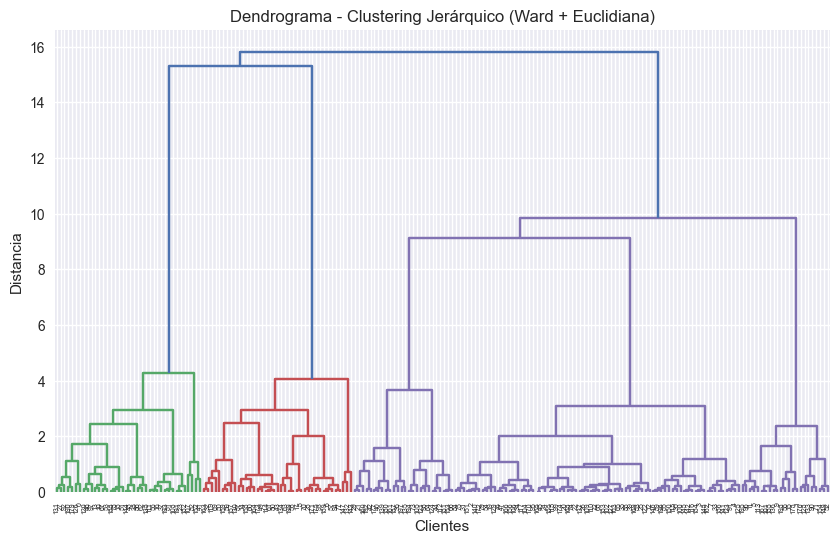

In [22]:
# Utilice este espacio para escribir el código.
# variables Ingreso y Puntaje_Gasto
X = df[["Ingreso", "Puntaje_Gasto"]].values

# Estandarizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Construcción del dendrograma con método Ward
linked = linkage(X_scaled, method="ward", metric="euclidean")

plt.figure(figsize=(10, 6))
dendrogram(linked,
           orientation="top",
           distance_sort="descending",
           show_leaf_counts=True)
plt.title("Dendrograma - Clustering Jerárquico (Ward + Euclidiana)")
plt.xlabel("Clientes")
plt.ylabel("Distancia")
plt.show()


(Utilice este espacio para describir su procedimiento)

Para construir el dendrograma se seleccionaron únicamente las variables Ingreso y Puntaje de Gasto, que son las más relevantes para el análisis de segmentación.

Antes de aplicar el clustering, se realizó la estandarización de las variables mediante StandardScaler, ya que ingreso y puntaje de gasto están en escalas muy diferentes (miles vs. valores pequeños).
La estandarización garantiza que ambas variables tengan media 0 y desviación estándar 1, evitando que el ingreso domine el cálculo de distancias.

Posteriormente se utilizó el método de enlace Ward, que minimiza la varianza dentro de los clusters, y la distancia Euclidiana, que es la más habitual en este tipo de análisis.

El dendrograma resultante permite visualizar cómo se van formando los grupos jerárquicos a diferentes niveles de distancia.

#### 3.2. Número de clusters

Retenga el número de clusters que se obtengan luego de fijar la distancia en 6.

Número de clusters (distancia=6): 5
   Id_Cliente  Genero  Edad   Ingreso  Puntaje_Gasto Grupo_Edad  Cluster
0           1   Mujer    41  98115.05             39      35-44        5
1           2   Mujer    20  35458.14             75      18-24        1
2           3   Mujer    68  59872.08             55        65+        2
3           4  Hombre    63  48508.93             51      55-64        2
4           5   Mujer    31  44431.11             54      25-34        2


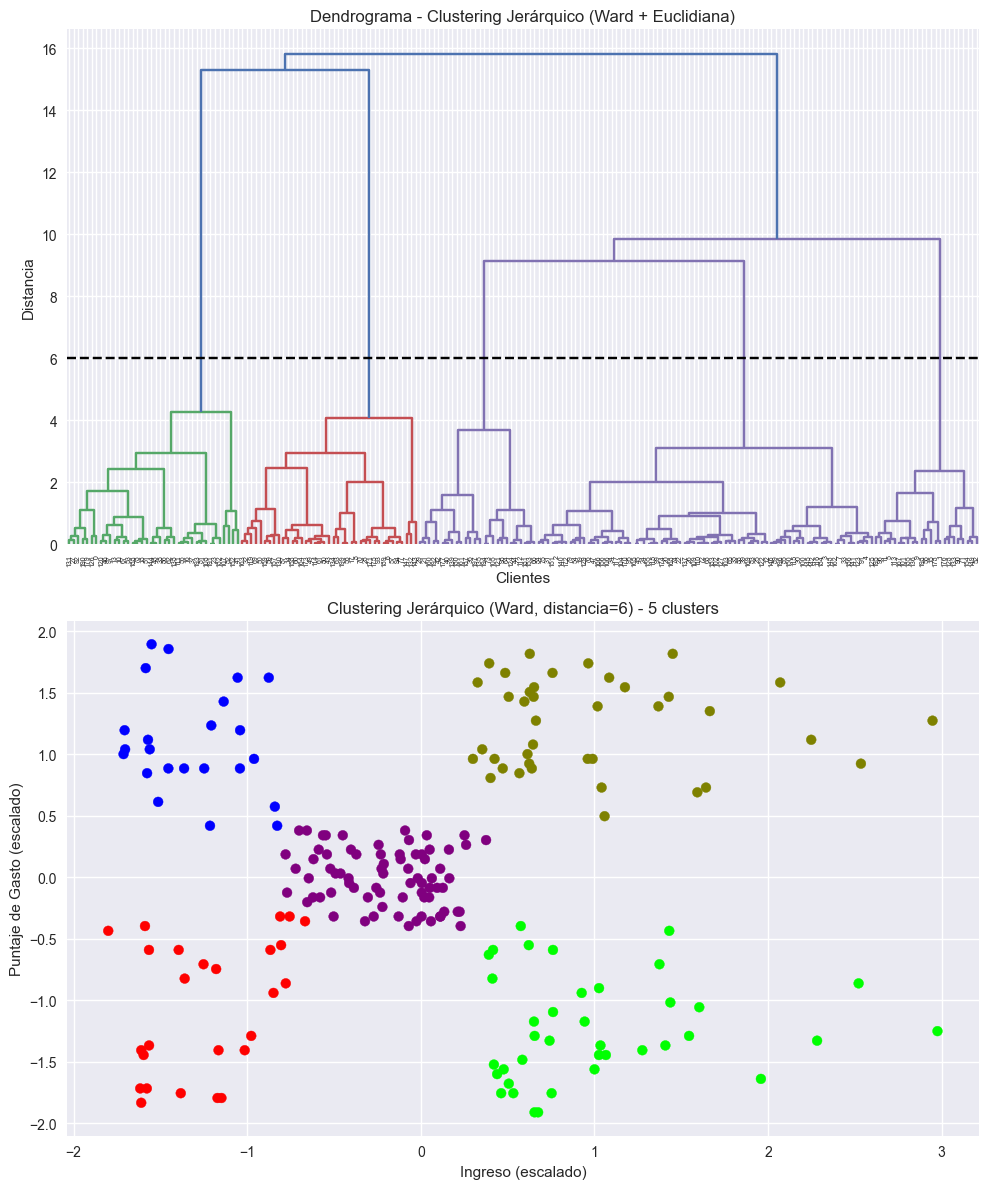

In [23]:
# Utilice este espacio para escribir el código.
# Cortar el dendrograma a una distancia de 6
distance = 6
clusters = fcluster(linked, t=distance, criterion="distance")

# Número de clusters resultantes
n_clusters = len(np.unique(clusters))
print(f"Número de clusters (distancia={distance}): {n_clusters}")

# Agregar los clusters al dataframe
df["Cluster"] = clusters
print(df.head())


_, axes = plt.subplots(2, 1, figsize=(10, 12))
axes = axes.flatten()  # Para indexar de manera lineal
# dendrogram
dendrogram(linked,
           orientation="top",
           distance_sort="descending",
           show_leaf_counts=True,
           ax=axes[0]
           )
axes[0].set_title("Dendrograma - Clustering Jerárquico (Ward + Euclidiana)")
axes[0].set_xlabel("Clientes")
axes[0].set_ylabel("Distancia")
axes[0].axhline(y=distance, color='black', linestyle='--', label='Threshold')

# clusters
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, cmap="brg", s=50, axes=axes[1])
axes[1].set_title(f"Clustering Jerárquico (Ward, distancia=6) - {n_clusters} clusters")
axes[1].set_xlabel("Ingreso (escalado)")
axes[1].set_ylabel("Puntaje de Gasto (escalado)")

plt.tight_layout()
plt.show()


(Utilice este espacio para describir su procedimiento)

Se fijó un umbral de distancia = 6 para cortar el dendrograma y determinar los clusters finales.
Con este valor, se obtuvieron 5 clusters distintos.

Posteriormente, se asignó a cada cliente una etiqueta de cluster y se visualizó tanto en el dendrograma (con línea de corte) como en el plano de las variables estandarizadas.

Esto permite observar tanto la separación jerárquica como la distribución real de los grupos en el espacio Ingreso–Gasto.

#### 3.3. Algoritmo Jerárquico Aglomerativo

Utilizando el número de clusters encontrados en el paso anterior, aplique el algoritmo jerárquico aglomerativo, utilizando el enlace 'ward' y la distancia euclidiana. Describa los grupos encontrados, en que grupo o grupos concentraría su estrategia de marketing y por qué?

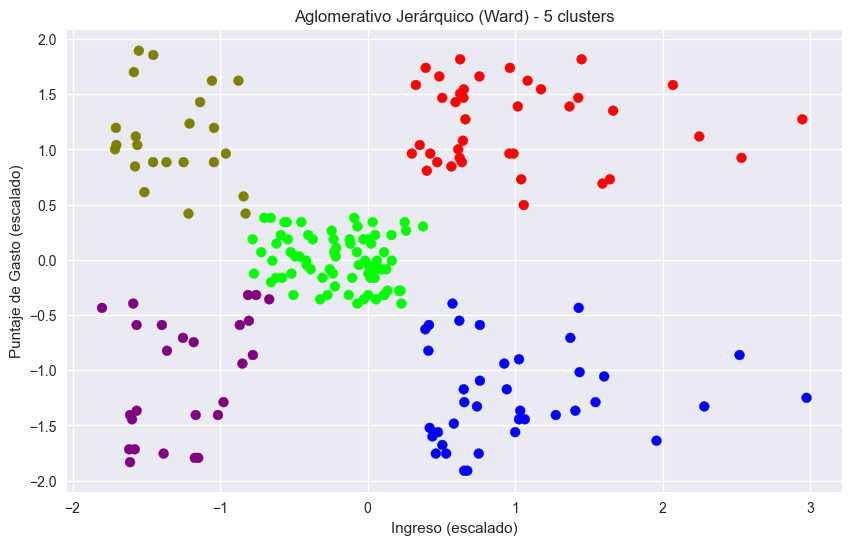

Resumen de clusters:
                   Ingreso  Puntaje_Gasto
Cluster_Agg                             
0            87055.074474      18.631579
1            28274.667308      23.307692
2            86537.496410      82.128205
3            26230.419565      78.565217
4            55451.258514      50.216216


In [24]:
# Utilice este espacio para escribir el código.
# Definir el número de clusters encontrados en el paso 3.2
agg = AgglomerativeClustering(
    n_clusters=n_clusters,   # número de clusters obtenido antes
    metric="euclidean",      # métrica de distancia (reemplaza affinity)
    linkage="ward"           # método de enlace
)

# Ajustar el modelo y obtener etiquetas
df["Cluster_Agg"] = agg.fit_predict(X_scaled)

# Visualización de clusters
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df["Cluster_Agg"], cmap="brg", s=50)
plt.title(f"Aglomerativo Jerárquico (Ward) - {n_clusters} clusters")
plt.xlabel("Ingreso (escalado)")
plt.ylabel("Puntaje de Gasto (escalado)")
plt.show()

# Resumen estadístico por cluster
cluster_summary = df.groupby("Cluster_Agg")[["Ingreso", "Puntaje_Gasto"]].mean()
print("Resumen de clusters:\n", cluster_summary)


(Utilice este espacio para describir su procedimiento)

Con el número de clusters definido en el paso anterior (5 clusters), se aplicó el algoritmo Aglomerativo Jerárquico con enlace Ward y distancia Euclidiana.

Esto permitió asignar cada cliente a uno de los grupos y calcular los promedios de ingreso y puntaje de gasto por cluster.

El resumen muestra los siguientes perfiles:

| Cluster | Ingreso Promedio | Gasto Promedio | Interpretación |
| --- | --- | --- | --- |
| 0 | ≈ 87,000 | ≈ 19 | Clientes de **altos ingresos pero bajo gasto**.|
| 1 | ≈ 28,000 | ≈ 23 | Clientes de **bajos ingresos y bajo gasto**. |
| 2 | ≈ 86,500 | ≈ 82 | Clientes de **altos ingresos y alto gasto**. |
| 3 | ≈ 26,200 | ≈ 79 | Clientes de **bajos ingresos pero alto gasto relativo**.|
| 4 | ≈ 55,400 | ≈ 50 | Clientes de **ingresos y gasto intermedios**. |


**Estrategia de Marketing**

Los grupos más atractivos para una campaña serían:

- *Cluster 2:* porque combina altos ingresos y alto gasto, lo que lo convierte en el segmento premium.

- *Cluster 3:* aunque con menores ingresos, tiene un alto gasto proporcional, lo que indica un perfil consumista a pesar de sus recursos limitados.

Los clusters 0 y 1 presentan bajo gasto, por lo que serían menos prioritarios en términos de rentabilidad, mientras que el cluster 4 representa un segmento medio, que podría responder a estrategias de fidelización o de valor agregado.

**Conclusión Final**

En el análisis jerárquico, tanto el corte del dendrograma (3.2) como el ajuste directo del modelo aglomerativo (3.3) producen los mismos grupos de clientes, dado que se emplea el mismo criterio de enlace (Ward) y la misma métrica de distancia (euclidiana).
La diferencia está en la visualización:

  - El dendrograma muestra el proceso jerárquico de cómo se van fusionando los grupos, y permite elegir un umbral de distancia para decidir el número de clusters.

  - El algoritmo aglomerativo recibe directamente el número de clusters como parámetro y asigna a cada cliente su grupo, facilitando la interpretación y el análisis de perfiles.

De esta forma, ambos enfoques son consistentes y complementarios: el dendrograma ayuda a decidir el número de clusters, y el aglomerativo permite explotarlos para segmentación y estrategia de marketing.

### 4. DBSCAN

Implemente DBSCAN, al igual que el punto anterior sólo dos variables: su ingreso y el puntaje de gastos. Al implementar  justifique su elección de `min_samples` y `eps`. ¿Cuántos grupos o clusters encuentra? ¿Cuáles son su características? ¿Cambiaría su estrategia de marketing respecto al punto anterior? Justifique su respuesta.

Mejores parámetros encontrados: eps=0.7000000000000002, min_samples=4
Mejor score de silueta: 0.4402


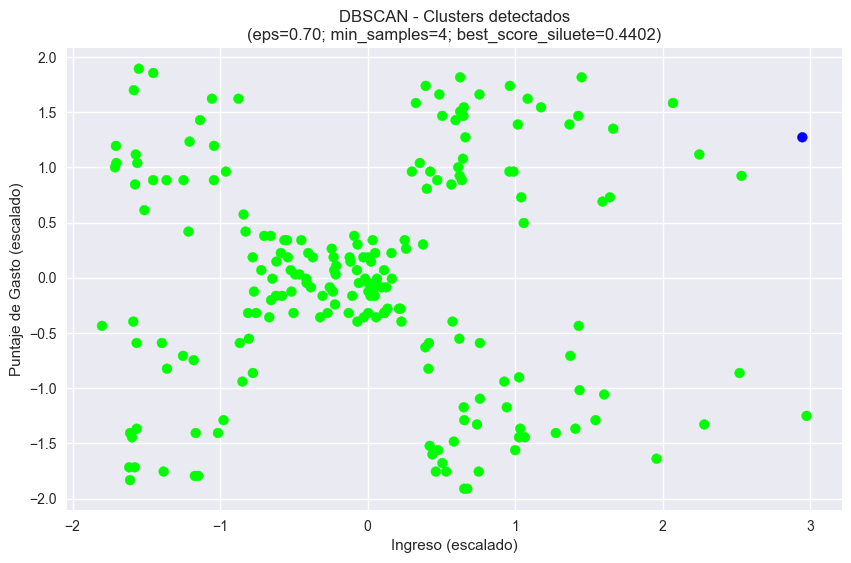

Resumen de clusters DBSCAN:
                      Ingreso  Puntaje_Gasto
Cluster_DBSCAN                             
-1              137838.57000      83.000000
 0               60236.43593      50.035176

Cantidad de elementos por cluster:
 Cluster_DBSCAN
-1      1
 0    199
Name: count, dtype: int64


In [25]:
# Variables a usar
X = df[["Ingreso", "Puntaje_Gasto"]].values
X_scaled = StandardScaler().fit_transform(X)

# Rango de parámetros a explorar
eps_values = np.arange(0.2, 1.2, 0.1)  # valores de eps entre 0.2 y 1.1
min_samples_values = range(3, 8)       # valores de min_samples entre 3 y 7

best_score = -1
best_params = None

# Búsqueda exhaustiva
for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric="euclidean")
        labels = dbscan.fit_predict(X_scaled)

        # DBSCAN puede asignar muchos puntos como ruido (-1), se evita casos extremos
        len_labels = len(set(labels))
        if len_labels > 1 and len_labels < len(X_scaled):
            try:
                score = silhouette_score(X_scaled, labels)
                if score > best_score:
                    best_score = score
                    best_params = (eps, min_samples)
            except:
                pass

print(f"Mejores parámetros encontrados: eps={best_params[0]}, min_samples={best_params[1]}")
print(f"Mejor score de silueta: {best_score:.4f}")

# Entrenar con los mejores parámetros
dbscan = DBSCAN(eps=best_params[0], min_samples=best_params[1], metric="euclidean")
df["Cluster_DBSCAN"] = dbscan.fit_predict(X_scaled)

# Visualización de clusters
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df["Cluster_DBSCAN"], cmap="brg", s=50)
plt.title(cleandoc(f"""
    DBSCAN - Clusters detectados
    (eps={best_params[0]:.2f}; min_samples={best_params[1]}; best_score_siluete={best_score:.4f})
"""))
plt.xlabel("Ingreso (escalado)")
plt.ylabel("Puntaje de Gasto (escalado)")
plt.show()

# Resumen estadístico por cluster
cluster_summary_dbscan = df.groupby("Cluster_DBSCAN")[["Ingreso", "Puntaje_Gasto"]].mean()
print("Resumen de clusters DBSCAN:\n", cluster_summary_dbscan)

# Cantidad de elementos por cluster
cluster_counts = df["Cluster_DBSCAN"].value_counts().sort_index()
print("\nCantidad de elementos por cluster:\n", cluster_counts)


(Utilice este espacio para describir su procedimiento)

Se consideró únicamente dos variables: el Ingreso anual y el Puntaje de gasto de los clientes.

Primero se normalizo los datos para que ambas variables estuvieran en la misma escala y posteriormente ajustamos el modelo.

La selección de los hiperparámetros eps (radio de vecindad) y min_samples (número mínimo de puntos para formar un cluster) es fundamental para que DBSCAN detecte adecuadamente la estructura en los datos.

En lugar de fijar los parámetros arbitrariamente, se efectuó una búsqueda exhaustiva variando eps entre 0.2 y 1.1, y min_samples entre 3 y 7. Para cada combinación calculamos el índice de silueta, que mide la calidad de la separación entre clusters. El modelo con mejor puntuación de silueta fue seleccionado.

Con los parámetros óptimos encontrados (eps=0.7, min_samples=4), DBSCAN produjo los siguientes resultados:

- El algoritmo identificó 1 cluster principal (Cluster 0) que agrupa a la gran mayoría de los clientes, caracterizados por un nivel de ingreso medio y un puntaje de gasto intermedio.

- Se detectó un solo cliente como ruido (Cluster -1), considerado un outlier, con ingresos significativamente más altos y puntaje de gasto también elevado en comparación con el resto.

En comparación con el algoritmo jerárquico aglomerativo, DBSCAN no logró encontrar 5 grupos diferenciados, ya que en este dataset la densidad de puntos no forma regiones claramente separadas más allá del gran cluster central.

**Respecto a la estrategia de marketing:**

- Para el Cluster 0, que concentra casi toda la población, sería recomendable diseñar campañas generales enfocadas en el consumidor promedio.

- Para el outlier (Cluster -1), se recomienda un análisis individualizado, dado que su perfil de ingreso y gasto lo hace especial y potencialmente interesante para una estrategia de marketing diferenciada o VIP.

En conclusión, en este caso DBSCAN resultó menos efectivo para segmentar clientes en múltiples grupos útiles para marketing, pero su valor añadido radica en la detección de outliers, que clustering jerárquico no reconocen explícitamente.

---

**Consideraciones**

*¿Por qué DBSCAN encontró menos clusters que el algoritmo jerárquico?*

- DBSCAN detecta clusters basándose en densidad de puntos dentro de un radio (eps).
- Si los datos no forman regiones densas y bien separadas, DBSCAN tiende a agruparlos en un único cluster grande.
- El clustering jerárquico fuerzan la partición en un número predefinido de grupos (ej. 5), aunque la separación no sea natural.

### 5. Incorporando más dimensiones

Hasta este momento hemos utilizado solo dos variables para nuestro análisis, sin embargo, la base cuenta con otras variables más: género y edad. Usando las categorías de edad creadas anteriormente incorpore género y grupo etario a su análisis. Genere los grupos utilizando DBSCAN y la distancia de Gower, justificando su elección de `min_samples` y `eps`   ¿Incorporar estas variables, ayuda a la focalización de la estrategia de marketing?

Mejores parámetros encontrados: eps=0.20, min_samples=3
Mejor score de silueta: 0.6443
Número de clusters encontrados (sin contar ruido): 12

Resumen de clusters:
                           Ingreso  Puntaje_Gasto  Genero Grupo_Edad
Cluster_DBSCAN_Gower                                                
0                     67841.233200      49.600000   Mujer      35-44
1                     44095.422941      58.647059   Mujer      18-24
2                     51517.958000      48.000000   Mujer        65+
3                     60525.942222      33.222222  Hombre      55-64
4                     62030.388387      66.903226   Mujer      25-34
5                     76241.613182      64.863636  Hombre      25-34
6                     46540.581429      49.000000  Hombre      18-24
7                     60734.389167      35.916667   Mujer      45-54
8                     48073.600000      41.700000  Hombre        65+
9                     68076.570000      50.250000  Hombre      35-44
10       

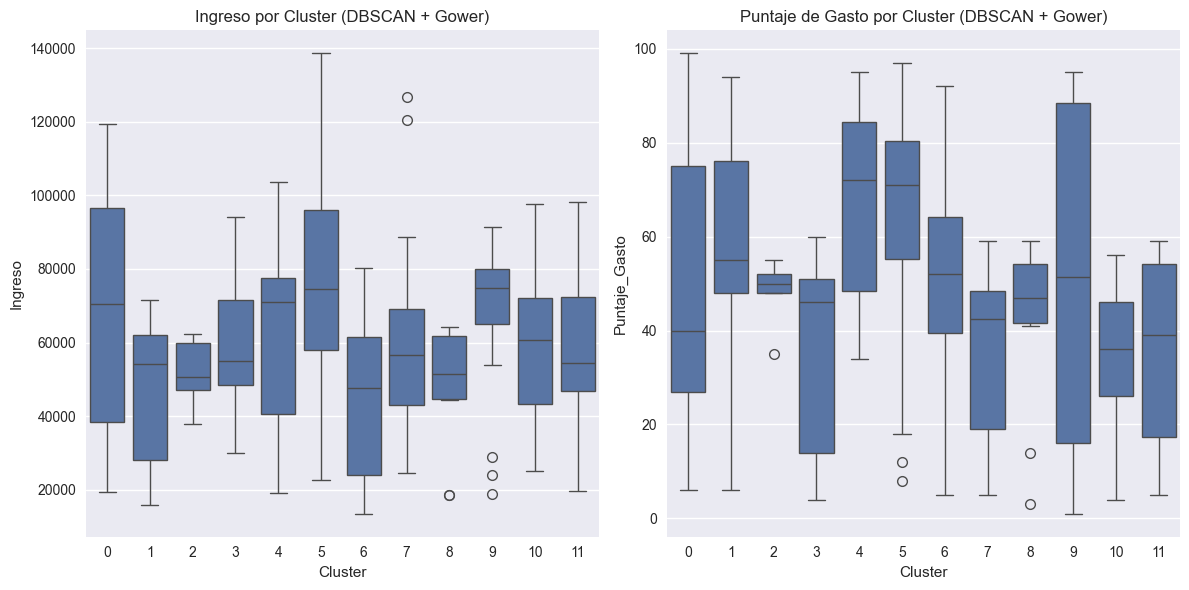

In [26]:
# Utilice este espacio para escribir el código.

# Crear variable Grupo_Edad
bins = [18, 24, 34, 44, 54, 64, np.inf]
labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df['Grupo_Edad'] = pd.cut(df['Edad'], bins=bins, labels=labels, right=False)

# Selección de variables
features = ["Ingreso", "Puntaje_Gasto", "Genero", "Grupo_Edad"]
X = df[features].copy()

# Asegurar variables categóricas como string
X["Genero"] = X["Genero"].astype(str)
X["Grupo_Edad"] = X["Grupo_Edad"].astype(str)

# Matriz de distancias de Gower
gower_dist = gower.gower_matrix(X)

# Búsqueda de parámetros
eps_values = np.arange(0.2, 1.0, 0.05)   # rango razonable para distancias Gower
min_samples_values = range(3, 8)

best_score = -1
best_params = None

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(metric="precomputed", eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(gower_dist)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        # Evitar casos extremos: todo ruido o un único cluster
        if n_clusters > 1 and n_clusters < len(df):
            try:
                score = silhouette_score(gower_dist, labels, metric="precomputed")
                if score > best_score:
                    best_score = score
                    best_params = (eps, min_samples)
            except:
                pass

print(f"Mejores parámetros encontrados: eps={best_params[0]:.2f}, min_samples={best_params[1]}")
print(f"Mejor score de silueta: {best_score:.4f}")

# Entrenamiento final con mejores parámetros
dbscan = DBSCAN(metric="precomputed", eps=best_params[0], min_samples=best_params[1])
df["Cluster_DBSCAN_Gower"] = dbscan.fit_predict(gower_dist)

# Resumen de clusters
num_clusters = len(set(df["Cluster_DBSCAN_Gower"])) - (1 if -1 in df["Cluster_DBSCAN_Gower"].values else 0)
print(f"Número de clusters encontrados (sin contar ruido): {num_clusters}")

# Promedios numéricos
num_summary = df.groupby("Cluster_DBSCAN_Gower")[["Ingreso", "Puntaje_Gasto"]].mean()

# Categorías dominantes
cat_summary = df.groupby("Cluster_DBSCAN_Gower")[["Genero", "Grupo_Edad"]] \
                .agg(lambda x: x.value_counts().index[0])

summary = pd.concat([num_summary, cat_summary], axis=1)
print("\nResumen de clusters:")
print(summary)

# Distribución de clientes por cluster
print("\nDistribución de clientes por cluster:")
print(df["Cluster_DBSCAN_Gower"].value_counts())

# Opcional: excluir ruido para los boxplots
df_plot = df.copy()
df_plot = df[df["Cluster_DBSCAN_Gower"] != -1]  # descomenta si no quieres mostrar -1

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.boxplot(data=df_plot, x="Cluster_DBSCAN_Gower", y="Ingreso")
plt.title("Ingreso por Cluster (DBSCAN + Gower)")
plt.xlabel("Cluster")

plt.subplot(1,2,2)
sns.boxplot(data=df_plot, x="Cluster_DBSCAN_Gower", y="Puntaje_Gasto")
plt.title("Puntaje de Gasto por Cluster (DBSCAN + Gower)")
plt.xlabel("Cluster")

plt.tight_layout(); plt.show()

(Utilice este espacio para describir su procedimiento)

En esta etapa se amplió el análisis de clustering para el DBSCAN incorporando variables categóricas (Género y Grupo_Edad), además de las continuas previamente consideradas.

Métrica utilizada:
Para manejar simultáneamente variables numéricas y categóricas se utilizó la distancia de Gower, la cual es apropiada para datos mixtos.

Selección de parámetros:

- Se exploró un rango de valores de eps entre 0.20 y 1.00, con saltos de 0.05.
- Se probaron valores de min_samples entre 3 y 7.
- Los parámetros se eligieron en función del índice de silueta, buscando la mayor separación entre clusters y evitando soluciones extremas (un solo cluster o todo ruido).
- La mejor combinación resultó ser eps = 0.20 y min_samples = 3, con un score de silueta = 0.6443, indicando una buena calidad de agrupamiento.

Resultados:
- Se identificaron 12 clusters, lo que contrasta con la Parte 4 (donde al usar solo las variables continuas se obtuvo esencialmente un único cluster con un outlier).
- La incorporación de variables categóricas permitió segmentar los clientes de manera más granular, diferenciando, por ejemplo, a mujeres jóvenes con alto puntaje de gasto de hombres de mayor edad con menor gasto.
- Esto refleja que las variables categóricas añaden valor para la interpretación y la focalización de estrategias de marketing.

Implicancias para marketing (contra la Parte 4):

- Los clusters muestran perfiles más ricos y diferenciados al considerar edad y género junto con ingreso y gasto.

- Ejemplos de segmentos detectados:

    Cluster 4: mujeres jóvenes (25–34) con ingreso ≈ 62,000 y gasto alto (≈ 67).
    Cluster 5: hombres jóvenes (25–34) con ingresos más altos (≈ 76,000) y gasto también elevado (≈ 65).
    Cluster 1: mujeres de 18–24, ingresos ≈ 44,000 y gasto medio-alto (≈ 59).
    Cluster 3 y 11: adultos de 55–64 con gasto bajo a medio.
    Cluster 2 y 8: adultos mayores (65+), con gasto bajo y perfiles diferenciados por género.

La distribución de clientes muestra grupos heterogéneos: los más poblados (clusters 4, 0, 7, 5, 9) concentran entre 20 y 31 clientes, mientras que los menos numerosos (clusters 2, 3, 8, 11) concentran entre 5 y 10.

En síntesis, la incorporación de más dimensiones no solo mejoró la calidad del clustering según el índice de silueta, sino que también generó segmentos más interpretables y útiles para la toma de decisiones en marketing.

---

Comparación con Partes 3, 4 y 5

- Parte 3 (jerárquico, 2 variables):
Encontró 5 clusters bien interpretables (premium, consumistas, altos ingresos/bajo gasto, etc.). Buena segmentación inicial pero con visión binaria de ingreso–gasto.

- Parte 4 (DBSCAN, 2 variables):
Colapsó a 1 cluster + 1 outlier → escasa utilidad para segmentación de marketing.

- Parte 5 (DBSCAN + Gower, 4 variables):
Produjo 12 clusters, es decir, una segmentación mucho más fina y granular, que captura diferencias de género y edad que antes quedaban ocultas.

---

Conclusión

- La Parte 5 ofrece una granularidad superior frente a la Parte 3: mientras el jerárquico separaba en 5 grupos, DBSCAN con Gower distingue 12 segmentos distintos.

- Esto permite estrategias de marketing mucho más focalizadas, por ejemplo:

    Campañas premium para hombres jóvenes (25–34, cluster 5) con altos ingresos y gasto elevado.
    Estrategias de fidelización para mujeres de mediana edad (35–44, cluster 0) con gasto intermedio.
    Productos financieros o promociones básicas para adultos mayores con gasto bajo (clusters 2 y 8).

En resumen: Parte 5 mejora sustancialmente la capacidad de focalización de la estrategia de marketing al incorporar más variables y lograr segmentaciones finas que no eran visibles en los análisis previos.